In [47]:
from qiskit_aer import AerSimulator
from qiskit import *
import supermarq
from qiskit.providers.fake_provider import *
import numpy as np 
import os

########## INPUT ############
f=5 # number of fake_backend want to choose
lower_limit= 3 # the lower limit of qubits for the circuit
upper_limit= 11 # the lower limit of qubits for the circuit
steps= 2 #jump in qubit numbers
name_of_algo='mermin_bell'

In [48]:
#all_fakes=[FakeAlmadenV2,FakeArmonkV2,FakeAthensV2,FakeAuckland,FakeBelemV2,FakeBoeblingenV2,FakeBogotaV2,FakeBrooklynV2,FakeBurlingtonV2,FakeCairoV2,FakeCambridgeV2,FakeCasablancaV2,FakeEssexV2,FakeGeneva,FakeGuadalupeV2,FakeHanoiV2,FakeJakartaV2,FakeJohannesburgV2,FakeKolkataV2,FakeLagosV2,FakeLimaV2,FakeLondonV2,FakeManhattanV2,FakeManilaV2,FakeMelbourneV2,FakeMontrealV2,FakeMumbaiV2,FakeNairobiV2,FakeOslo,FakeOurenseV2,FakeParisV2,FakePerth,FakePrague,FakePoughkeepsieV2,FakeQuitoV2,FakeRochesterV2,FakeRomeV2,FakeSantiagoV2,FakeSherbrooke,FakeSingaporeV2,FakeSydneyV2,FakeTorontoV2,FakeValenciaV2,FakeVigoV2,FakeWashingtonV2,FakeYorktownV2]
#selected_fakes = random.sample(all_fakes, f)
#selected_fakes  # having any randomly selected 5 fake backends out of 46 mentioned in the inital list
selected_fakes=[FakeBoeblingenV2,FakeRomeV2,FakeGeneva,FakeTorontoV2,FakeRochesterV2]

In [49]:
benchmarks=[]
for i in range(lower_limit,upper_limit,steps):
    label = name_of_algo+str(i)
    benchmarks.append((supermarq.mermin_bell.MerminBell(i),label))
for i in benchmarks:
    circuit=i[0].qiskit_circuit()
    print("--------------------------",i[1],"---------------------------")
    #circuit.draw(output="mpl")
    #print(circuit.draw())       #uncomment it to print all the circuits

-------------------------- marmin_bell3 ---------------------------
-------------------------- marmin_bell5 ---------------------------
-------------------------- marmin_bell7 ---------------------------
-------------------------- marmin_bell9 ---------------------------


In [50]:
benchmark_features = {}
for benchmark, label in benchmarks:
    benchmark_features[label] = [
        supermarq.converters.compute_communication_with_qiskit(benchmark.qiskit_circuit()),
        supermarq.converters.compute_depth_with_qiskit(benchmark.qiskit_circuit()),
        supermarq.converters.compute_entanglement_with_qiskit(benchmark.qiskit_circuit()),
        supermarq.converters.compute_liveness_with_qiskit(benchmark.qiskit_circuit()),
        supermarq.converters.compute_measurement_with_qiskit(benchmark.qiskit_circuit()),
        supermarq.converters.compute_parallelism_with_qiskit(benchmark.qiskit_circuit()),]
print(benchmark_features)

{'marmin_bell3': [1.0, 1.0, 0.4375, 0.6666666666666666, 0.0, 0.11538461538461542], 'marmin_bell5': [1.0, 0.8947368421052632, 0.5588235294117647, 0.5043478260869565, 0.0, 0.11956521739130432], 'marmin_bell7': [1.0, 0.7714285714285715, 0.625, 0.42424242424242425, 0.0, 0.11616161616161617], 'marmin_bell9': [1.0, 0.6727272727272727, 0.6707317073170732, 0.3772609819121447, 0.0, 0.11337209302325582]}


In [51]:
import time
import pandas as pd
from IPython.display import display
jobs =[]
data=[]
print("=============SCORES OF ALL THE CIRCUITS=============")    
for backend in selected_fakes:
    print("BACKEND-NAME :: ", backend().name)
    for benchmark, label in benchmarks:
        circuit=benchmark.qiskit_circuit()
        score_list=[]
        timetaken=[]
        for i in range(0,1):
            start=time.time()
            job = backend().run(circuit, shots=1000)
            result = job.result()
            counts = job.result(0).get_counts()
            score = benchmark.score(counts)
            end=time.time()-start
            score_list.append(score)
            t=job.result(0).time_taken
            timetaken.append(t)
            print(i+1,"th iteration,", label ," Execution time::",t, "Total Time Taken ::",end )
            #print(label ," ExecutionTime:",t,"& Total time:",end)
        #print("------------------------------------------")
        score = np.mean(score_list) 
        sd = np.std(score_list)
        execution_time = np.mean(timetaken)
        dictionary={}
        dictionary["Backend_Time"]=backend().name
        dictionary["Ciruit_Name"]=label    
        dictionary["Execution_Time"]=execution_time
        dictionary["Total_Time"]=end
        data.append(dictionary)
        jobs.append((label,benchmark,backend,job,score,sd,execution_time,end))
#jobs
df = pd.DataFrame(data)
display(df)
df.to_excel(r"./output_Mermin_Bell.xlsx", index=False)

=============SCORES OF ALL THE CIRCUITS=============
BACKEND-NAME ::  fake_boeblingen
1 th iteration, marmin_bell3  Execution time:: 0.07928156852722168 Total Time Taken :: 0.31677937507629395
1 th iteration, marmin_bell5  Execution time:: 0.07729125022888184 Total Time Taken :: 0.4508676528930664
1 th iteration, marmin_bell7  Execution time:: 0.08137178421020508 Total Time Taken :: 0.44762349128723145
1 th iteration, marmin_bell9  Execution time:: 0.09349417686462402 Total Time Taken :: 0.5422859191894531
BACKEND-NAME ::  fake_rome
1 th iteration, marmin_bell3  Execution time:: 0.023030519485473633 Total Time Taken :: 0.07929778099060059
1 th iteration, marmin_bell5  Execution time:: 0.023072242736816406 Total Time Taken :: 0.07907319068908691
1 th iteration, marmin_bell7  Execution time:: 0.024087905883789062 Total Time Taken :: 0.09267115592956543
1 th iteration, marmin_bell9  Execution time:: 0.03575634956359863 Total Time Taken :: 0.14624476432800293
BACKEND-NAME ::  fake_geneva
1

,Backend_Time,Ciruit_Name,Execution_Time,Total_Time
0,fake_boeblingen,marmin_bell3,0.079282,0.316779
1,fake_boeblingen,marmin_bell5,0.077291,0.450868
2,fake_boeblingen,marmin_bell7,0.081372,0.447623
3,fake_boeblingen,marmin_bell9,0.093494,0.542286
4,fake_rome,marmin_bell3,0.023031,0.079298
5,fake_rome,marmin_bell5,0.023072,0.079073
6,fake_rome,marmin_bell7,0.024088,0.092671
7,fake_rome,marmin_bell9,0.035756,0.146245
8,fake_geneva,marmin_bell3,0.351481,0.925966
9,fake_geneva,marmin_bell5,0.155530,0.772607


In [52]:
all_scores={}  
all_fake_names=[]
all_fake_scores=[]
for i in selected_fakes:
    fakes=i
    #print("SELCETED_FAKES:: ",i)
    i={}
    for label,benchmark,backend,job,score,sd,exec,tot in jobs:
        #supermarq.plotting.plot_results([score], [label])
        if fakes == backend:
            i[label] = score
    device_scores = 'device_score_' +str(fakes().name)
    all_scores[device_scores]= i
    all_fake_scores.append(i)
    all_fake_names.append(device_scores)   
#print(all_scores)    

In [53]:
for label,benchmark,backend,job,score,sd,exec,tot in jobs:
    print("USED BACKEND::",backend().name,"; CIRCUIT_NAME:",label, "; SCORE =",score)
    #supermarq.plotting.plot_results([score], [label]) #uncomment it to print all the circuits
    #print("-----------------------------------------------------------")

USED BACKEND:: fake_boeblingen ; CIRCUIT_NAME: marmin_bell3 ; SCORE = 0.4935
USED BACKEND:: fake_boeblingen ; CIRCUIT_NAME: marmin_bell5 ; SCORE = 0.5005
USED BACKEND:: fake_boeblingen ; CIRCUIT_NAME: marmin_bell7 ; SCORE = 0.499
USED BACKEND:: fake_boeblingen ; CIRCUIT_NAME: marmin_bell9 ; SCORE = 0.5
USED BACKEND:: fake_rome ; CIRCUIT_NAME: marmin_bell3 ; SCORE = 0.4835
USED BACKEND:: fake_rome ; CIRCUIT_NAME: marmin_bell5 ; SCORE = 0.5
USED BACKEND:: fake_rome ; CIRCUIT_NAME: marmin_bell7 ; SCORE = 0.5
USED BACKEND:: fake_rome ; CIRCUIT_NAME: marmin_bell9 ; SCORE = 0.5
USED BACKEND:: fake_geneva ; CIRCUIT_NAME: marmin_bell3 ; SCORE = 0.4875
USED BACKEND:: fake_geneva ; CIRCUIT_NAME: marmin_bell5 ; SCORE = 0.4995
USED BACKEND:: fake_geneva ; CIRCUIT_NAME: marmin_bell7 ; SCORE = 0.5005
USED BACKEND:: fake_geneva ; CIRCUIT_NAME: marmin_bell9 ; SCORE = 0.5
USED BACKEND:: fake_toronto ; CIRCUIT_NAME: marmin_bell3 ; SCORE = 0.478
USED BACKEND:: fake_toronto ; CIRCUIT_NAME: marmin_bell5 ; 

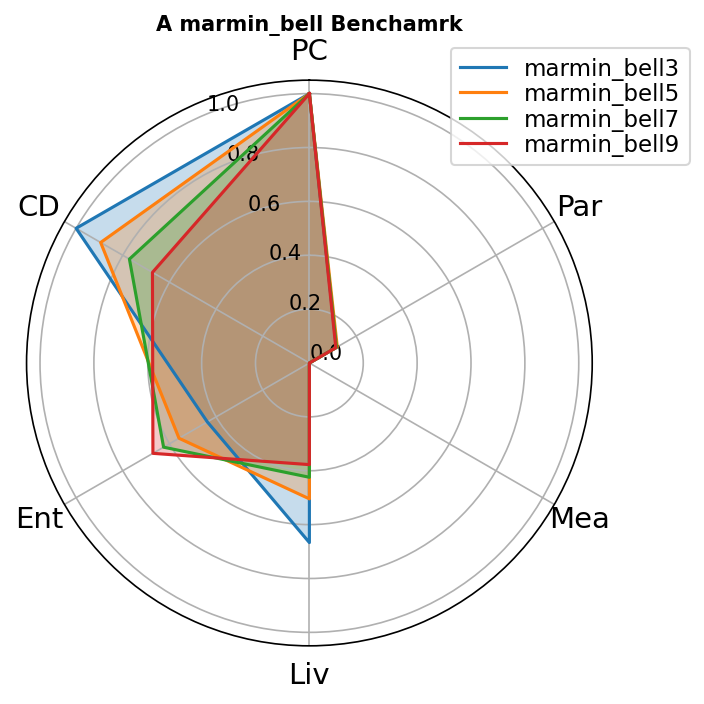

In [54]:
names=[]
scores=[]
X="A "+name_of_algo+' Benchamrk'
for i,j in benchmark_features.items():
    names.append(i)
    scores.append(j)
supermarq.plotting.plot_benchmark([X,names,scores],
        spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"],show=True)

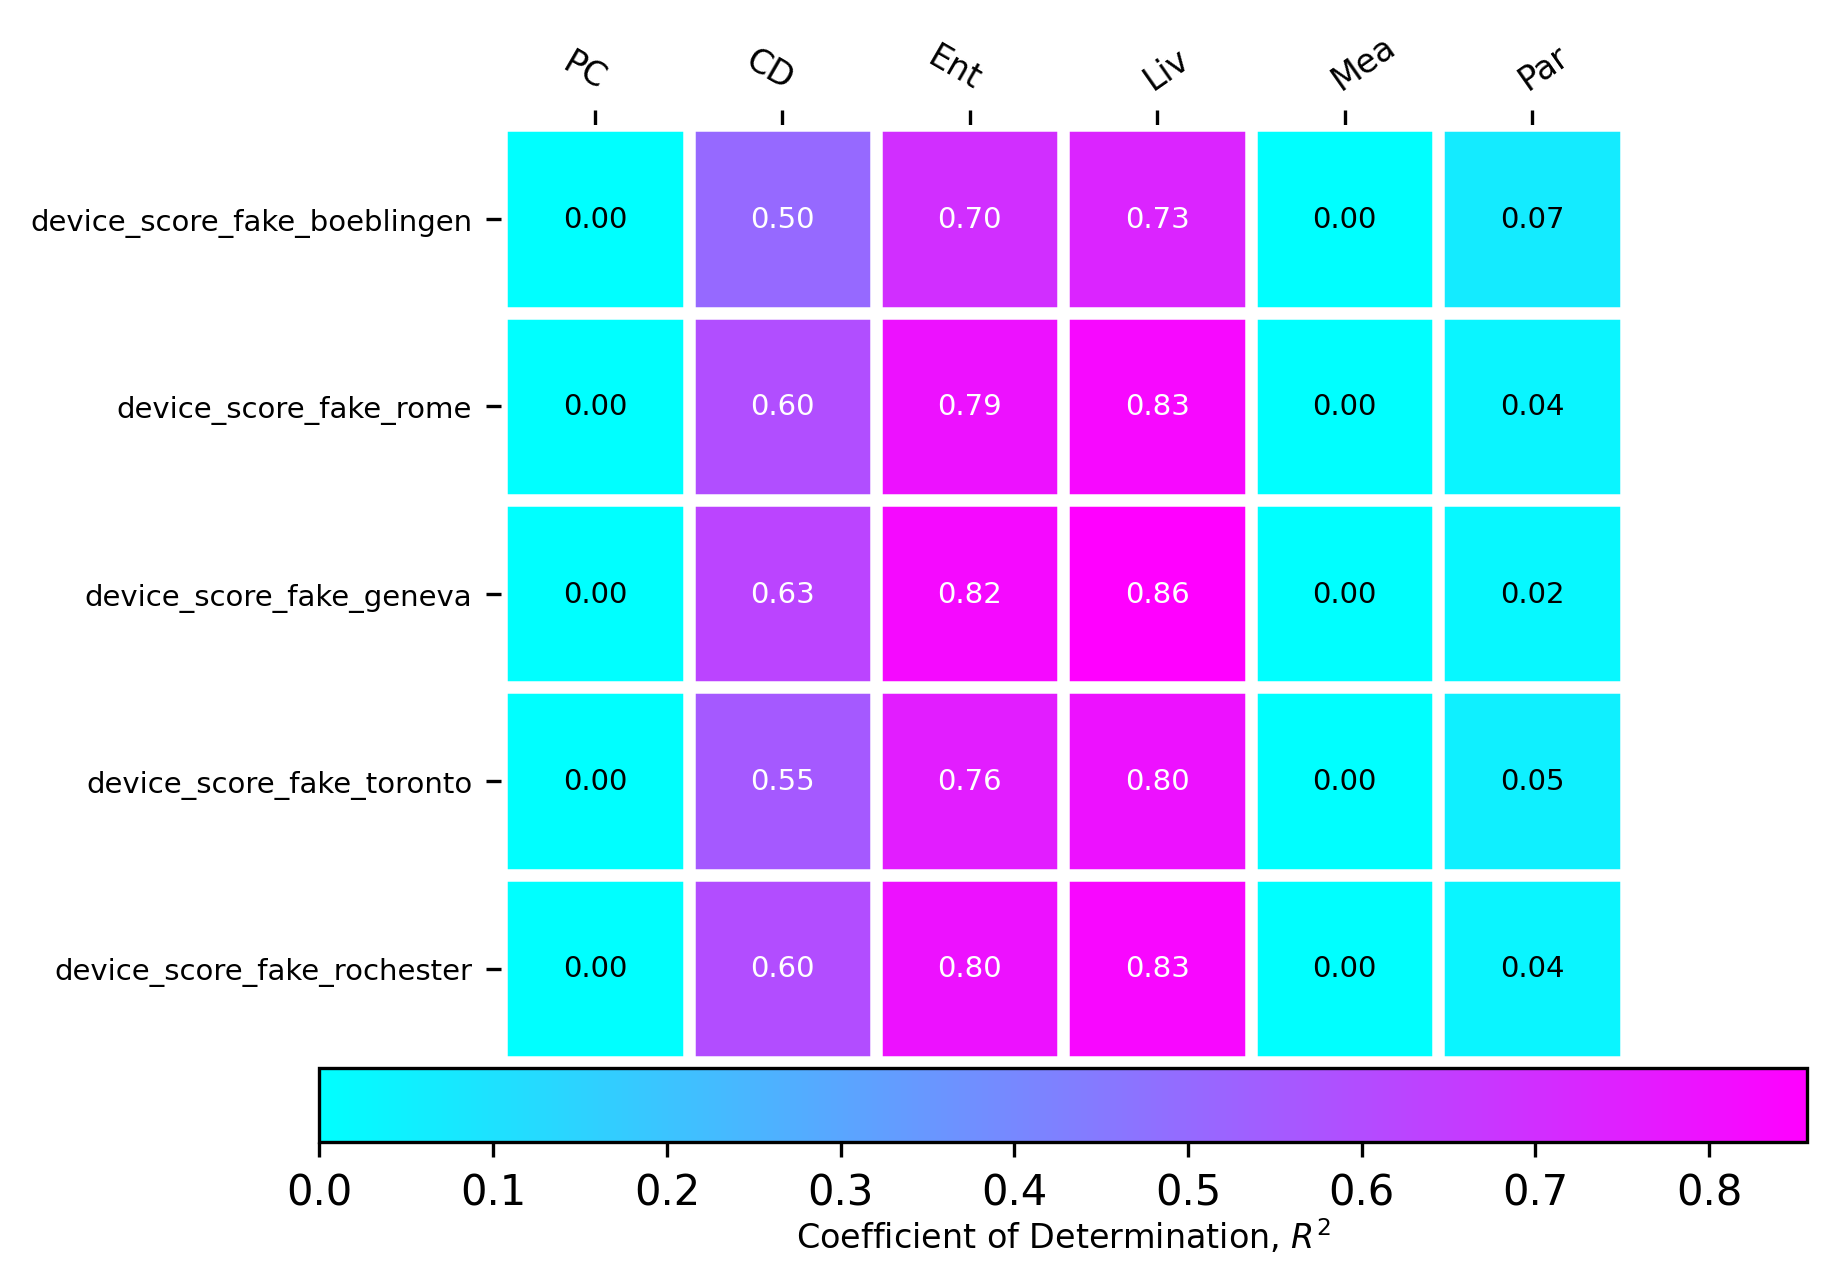

In [55]:
supermarq.plotting.plot_correlations(benchmark_features,all_fake_scores,["PC", "CD", "Ent", "Liv", "Mea", "Par"],device_name=all_fake_names,show=True,)

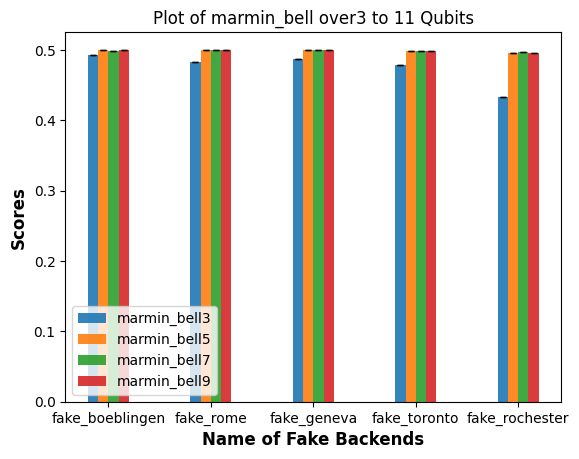

In [56]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np
all_fake_names=[]
all_score=[]
all_sd=[]
all_ckt=[]
v='Plot of '+name_of_algo+' over'+str(lower_limit)+' to '+str(upper_limit)+ ' Qubits'
for i in selected_fakes:
    all_fake_names.append(i().name)    
for benchmark, label in benchmarks:
    i=[]
    j=[]
    k=[]
    for ckt,benchmark,backend,job,score,sd,exec,tot in jobs:
        if ckt == label:
            i.append(score)
            j.append(sd)
    all_ckt.append(label)
    all_score.append(i)
    all_sd.append(j)
num_bars = len(all_score)
width = 0.1
x = np.arange(len(all_fake_names)) # x-axis positions for each bar
fig, ax = plt.subplots()
for i in range(num_bars):               # Create bars for each category with appropriate offsets
    ax.bar(x + i * width, all_score[i], width=width, label=f'Bar {i+1}', 
           yerr=all_sd[i],align='center',alpha=0.9,ecolor='black',capsize=2)
ax.set_xlabel('Name of Fake Backends',fontweight ='bold',fontsize = 12)
ax.set_ylabel('Scores',fontweight ='bold',fontsize = 12)
ax.set_title(v)
ax.set_xticks(x + (num_bars - 1) * width / 2)
ax.set_xticklabels(all_fake_names)
ax.legend(all_ckt,loc="lower left")
#ax.grid(True)
plt.show()

In [57]:
import resource
def get_memory():
    usage = resource.getrusage(resource.RUSAGE_SELF)
    max_mem = usage.ru_maxrss/1024 #in MB
    return max_mem
get_memory()

671.09765625